## 저장한 모델 사용하기

## 사전학습모델
- ResNet18 사용

### 1. 라이브러리 로드

In [18]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

import requests
from PIL import Image
from io import BytesIO
import os
import random
import shutil

# 사전학습 모델 라이브러리 추가
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# pip install icrawler
# 웹사이트에서 필요한걸 긁어오는 라이브러리
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler

import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### 2. 설정

In [3]:
model_path = 'resnet18_bird_cat_dog.pth'
test_dir = 'dataset/test'

num_classes = 3
batch_size = 16

### 3. .ResNet18 모델구조 재생성

In [5]:
weight = ResNet18_Weights.DEFAULT
model = resnet18(weights = weight)

model.fc = nn.Linear(
    in_features = model.fc.in_features,
    out_features = num_classes
)
model = model.to(device=device)

### 4. pth 모델 파일 로드

In [7]:
model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### 5. 전처리설정

In [8]:
preprocess = weight.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 6. 바이두 이미지크롤링
- 테스트이미지셋 다운로드

In [9]:
# 추가설정
testset_dir = 'dataset/test'

classes = {
    'dog photo': 'dog',
    'cat photo': 'cat',
    'bird photo': 'bird'
}

num_epoch = 5
lr = 0.001

### 

In [10]:
# 테스트이미지 폴더
for keyword, class_name in classes.items():
    save_dir = os.path.join(testset_dir, class_name)
    os.makedirs(save_dir, exist_ok=True)

    crawler = BaiduImageCrawler(
        storage={'root_dir': save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=150
    )

2026-05-21 15:57:38,186 - INFO - icrawler.crawler - start crawling...
2026-05-21 15:57:38,187 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 15:57:38,188 - INFO - feeder - thread feeder-001 exit
2026-05-21 15:57:38,189 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 15:57:38,192 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 15:57:39,391 - INFO - parser - parsing result page http://image.baidu.com/search/acjson?tn=resultjson_com&ipn=rj&word=dog photo&pn=0&rn=30
2026-05-21 15:57:40,228 - INFO - downloader - image #1	https://gimg2.baidu.com/image_search/src=http%3A%2F%2Fss2.meipian.me%2Fusers%2F50628749%2Fc5916810-a512-11ef-92fd-2d0d6eaec733.jpg%3FimageView2%2F2%2Fw%2F750%2Fh%2F1400%2Fq%2F80&refer=http%3A%2F%2Fss2.meipian.me&app=2002&size=f9999,10000&q=a80&n=0&g=0n&fmt=auto?sec=1781938659&t=2263b135f1b42829ca71c13e0d13bc57
2026-05-21 15:57:40,938 - INFO - downloader - image #2	https://hellorfimg.zcool.cn/large/2547222029.j

### 7. test 데이터셋 불러오기

In [12]:
test_dataset = ImageFolder(
    root = testset_dir,
    transform = preprocess
)
test_dataset.classes

['bird', 'cat', 'dog']

In [13]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

### 8. test 정확도 확인

In [15]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to (device)

        outputs = model(images)

        _, predict = torch.max(outputs, 1)

        correct += (predict == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total

print(f'테스트 정확도 : {test_acc:.4f}')
        

테스트 정확도 : 0.8844


### 9. 실제/예측값 출력

In [17]:
class_names = test_dataset.classes

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to (device)

        outputs = model(images)

        prob = torch.softmax(outputs, dim = 1)
        confidence, predict = torch.max(prob, 1)

        for i in range(len(labels)):
            true_label = class_names[labels[i].item()]
            pred_label = class_names[predict[i].item()]
            conf = confidence[i].item();

            print(f'실제 : {true_label} / 예측 : {pred_label} / 확률 : {conf:.4f}')

실제 : bird / 예측 : bird / 확률 : 0.9168
실제 : bird / 예측 : bird / 확률 : 0.9588
실제 : bird / 예측 : bird / 확률 : 0.6526
실제 : bird / 예측 : bird / 확률 : 0.8112
실제 : bird / 예측 : bird / 확률 : 0.8808
실제 : bird / 예측 : bird / 확률 : 0.9633
실제 : bird / 예측 : bird / 확률 : 0.9956
실제 : bird / 예측 : bird / 확률 : 0.9770
실제 : bird / 예측 : bird / 확률 : 0.9872
실제 : bird / 예측 : bird / 확률 : 0.9398
실제 : bird / 예측 : bird / 확률 : 0.9801
실제 : bird / 예측 : bird / 확률 : 0.9337
실제 : bird / 예측 : bird / 확률 : 0.9323
실제 : bird / 예측 : bird / 확률 : 0.9584
실제 : bird / 예측 : bird / 확률 : 0.8436
실제 : bird / 예측 : bird / 확률 : 0.9734
실제 : bird / 예측 : bird / 확률 : 0.9735
실제 : bird / 예측 : bird / 확률 : 0.9391
실제 : bird / 예측 : bird / 확률 : 0.9884
실제 : bird / 예측 : bird / 확률 : 0.9527
실제 : bird / 예측 : bird / 확률 : 0.9618
실제 : bird / 예측 : bird / 확률 : 0.8766
실제 : bird / 예측 : bird / 확률 : 0.8682
실제 : bird / 예측 : bird / 확률 : 0.9495
실제 : bird / 예측 : bird / 확률 : 0.9577
실제 : bird / 예측 : bird / 확률 : 0.9902
실제 : bird / 예측 : bird / 확률 : 0.9233
실제 : bird / 예측 : bird / 확률 :

### 10. 시각화

2026-05-21 16:58:06,209 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
2026-05-21 16:58:06,216 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
2026-05-21 16:58:06,223 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.2739873].
2026-05-21 16:58:06,232 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
2026-05-21 16:58:06,240 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.622571].
2026-05-21 

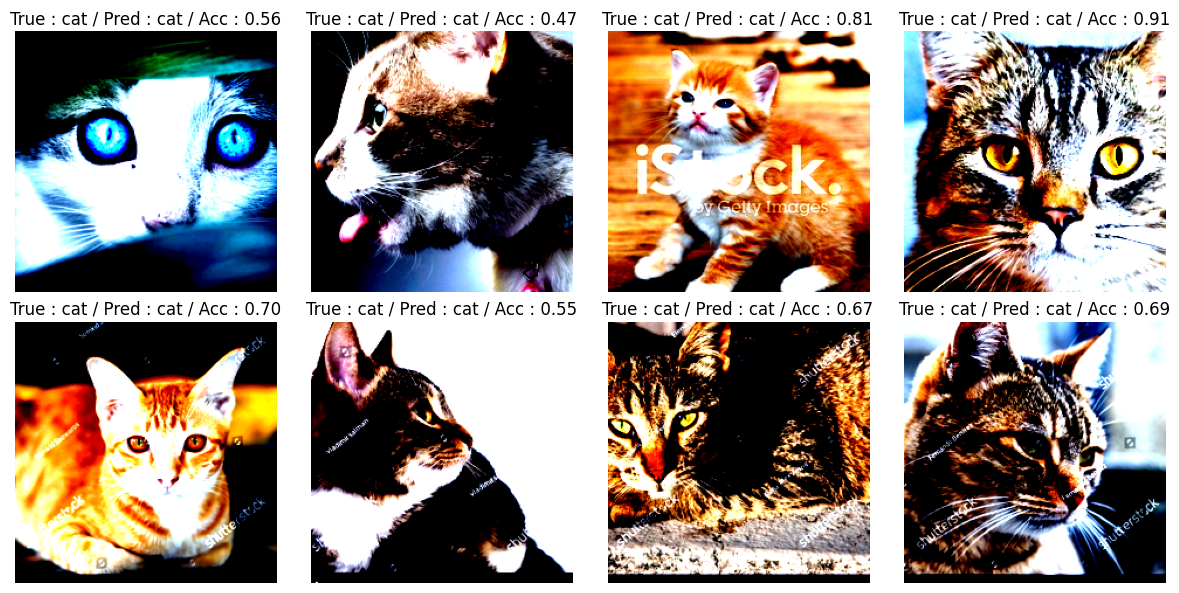

In [27]:
batch_size=8
all_batches = list(test_loader)
images, labels = all_batches[6]


model.eval()

with torch.no_grad():
    outputs = model(images.to(device))

    prob = torch.softmax(outputs, dim=1)
    confidence, predict = torch.max(prob, 1)

plt.figure(figsize=(12, 6))

for i in range(min(8, len(images))):
    image = images[i].permute(1, 2, 0).numpy()

    true_label = class_names[labels[i].item()]
    pred_label = class_names[predict[i].item()]
    
    conf = confidence[i].item()

    # 2행 4열 형태로 이미지 출력
    plt.subplot(2, 4, i+1)
    plt.imshow(image)

    # 기존의 plt.title 코드를 지우고, 아래처럼 'conf'로 바꾸기만 하면 됩니다!
    plt.title(f'True : {true_label} / Pred : {pred_label} / Acc : {conf:.2f}')
    plt.axis('off')

plt.tight_layout()
plt.show()